In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as spst


In [2]:
# Canonical implementations of the functions defined below live in
# src/etf_bandit/. Importing them here makes them available under the
# same names used throughout this notebook. Any later cell that defines
# a function with the same name will simply override the import.

from etf_bandit import (
    panel as _panel, volatility as _vol,
    beliefs as _beliefs,
    models_studentt as _studentt,
    models_contextual as _ctx,
    policy as _policy, backtest as _bt,
)

validate_panel = _panel.validate_panel
global_volatility = _vol.global_volatility
init_belief_state_studentt = _beliefs.init_belief_state
update_beliefs_studentt = _beliefs.update_beliefs
studentt_birth_prior_mean = _beliefs.birth_prior_mean
init_states_studentt = _studentt.init_states
ensure_states_studentt = _studentt.ensure_states
update_states_studentt = _studentt.update_states
scores_studentt_v2 = _studentt.scores_v2
scores_studentt_v3_topN = _studentt.scores_v3_topN
init_states_studentt_contextual = _ctx.init_states
ensure_states_studentt_contextual = _ctx.ensure_states
update_states_studentt_contextual = _ctx.update_states
scores_studentt_contextual_v2_predvar = _ctx.scores_predvar
scores_studentt_contextual_v2_predvar_topN = _ctx.scores_predvar_topN
scores_to_weights = _policy.scores_to_weights
turnover = _policy.turnover
portfolio_return_for_month = _policy.portfolio_return_for_month
run_policy_simulation_studentt_v3_topN_warm = _bt.run_studentt_topN
run_policy_simulation_studentt_contextual_topN = _bt.run_contextual_topN
run_cash_strategy = _bt.run_cash
run_buy_hold_spy = _bt.run_buy_hold_spy


## Initialization and Data Loading

In [3]:
# Loading Data

data=pd.read_csv("./data/final_dataset.csv")
df =data.copy().drop(columns=["Unnamed: 0"], errors="ignore")

# cleaning

df["Month"] = pd.to_datetime(df["Month"])

# Sort by time then ETF (important for sanity and reproducibility)
df = df.sort_values(["Month", "ETF"]).reset_index(drop=True)

# Ensure tag columns are integers (0/1)
TAG_COLS = [
    "is_equity",
    "is_international",
    "is_gov",
    "is_credit",
    "is_macro"
]

for c in TAG_COLS:
    df[c] = df[c].astype(int)

df.head()

,Month,Open,Close,Growth,ETF,rf_month,outperformed,excess_return,months_outperforming,TB3MS_lag1,...,inflation_yoy_lag1,inflation_shock_lag1,yield_slope_lag1,credit_spread_lag1,VIXCLS_lag1,is_equity,is_international,is_gov,is_credit,is_macro
0,1993-01-31,43.96875,43.93750,-0.000711,SPY,0.002466,0,-0.003177,0,3.22,...,0.029667,-0.001032,3.550000,2.040000,12.191364,1,0,0,0,0
1,1993-02-28,43.96875,44.40625,0.009950,SPY,0.002409,1,0.007541,0,3.00,...,0.032538,0.000842,3.600000,2.070000,12.409000,1,0,0,0,0
2,1993-03-31,44.56250,45.18750,0.014025,SPY,0.002426,1,0.011600,1,2.93,...,0.032468,-0.000566,3.328947,2.131053,13.721579,1,0,0,0,0
3,1993-04-30,45.25000,44.03125,-0.026934,SPY,0.002361,0,-0.029294,2,2.95,...,0.030194,-0.001085,3.025217,2.174783,13.606087,1,0,0,0,0
4,1993-05-31,44.09375,45.21875,0.025514,SPY,0.002434,1,0.023080,0,2.87,...,0.031564,0.000896,3.099524,2.170476,12.840952,1,0,0,0,0


In [4]:
validate_panel(df)

In [5]:
# Configuring Constants

# (TAG_COLS, MACRO_COLS)
# (ESS_B, alpha0, beta0, eps_B)
# (nu, var_window, mc_N, eps_s, tau0)

TAG_COLS = [
    "is_equity",
    "is_international",
    "is_gov",
    "is_credit",
    "is_macro",
]

MACRO_COLS = [
    "TB3MS_lag1",
    "dTB3MS_lag1",
    "UNRATE_lag1",
    "inflation_yoy_lag1",
    "inflation_shock_lag1",
    "yield_slope_lag1",
    "credit_spread_lag1",
    "VIXCLS_lag1",
]

MONTH_COL = "Month"
ETF_COL   = "ETF"

GROWTH_COL = "Growth"         # actual ETF return for accounting
RET_COL   = "excess_return"   # continuous excess return x_{i,t}
BIN_COL   = "outperformed"    # binary 1{x_{i,t} > 0}
RF_COL    = "rf_month"        # monthly risk-free rate

# bernoulli params
ESS_B = 10
alpha0, beta0 = 2.0, 2.0
epsilon_B = 1e-8

# student-t params
nu = 5
vol_window = 12
mc_N = 2000
eps_s = 0.0005
tau0 = 0.05

# rng for reproducability
seed = 123
rng = np.random.default_rng(seed)

### Column constants and train-only macro z-scoring


In [6]:
MONTH_COL = "Month"  # whatever yours is
df[MONTH_COL] = pd.to_datetime(df[MONTH_COL])

split_date = pd.Timestamp("2014-12-31")
df_train = df[df[MONTH_COL] <= split_date].copy()
df_test  = df[df[MONTH_COL] >  split_date].copy()

Z_COLS = MACRO_COLS          # your lagged macro columns
USE_INTERCEPT = True

def make_z_vec_from_df(df_t):
    """
    Build z_t (context vector) from the decision-month dataframe df_t.
    Assumes macro columns are constant within month; takes the first row.
    Returns shape (d,).
    """
    row0 = df_t.iloc[0]
    z = row0[Z_COLS].astype(float).values
    if USE_INTERCEPT:
        z = np.concatenate(([1.0], z))
    return z

In [7]:
Z_mean = df_train[Z_COLS].mean()
Z_std  = df_train[Z_COLS].std(ddof=0).replace(0.0, 1.0)  # avoid divide-by-zero

def apply_zscore(df_in):
    df_out = df_in.copy()
    df_out[Z_COLS] = (df_out[Z_COLS] - Z_mean) / Z_std
    return df_out

df_train = apply_zscore(df_train)
df_test  = apply_zscore(df_test)

# (Optional) also create a standardized full df for full-sample descriptive plots
df_std = apply_zscore(df)

## Results tracking

In [8]:
WEALTH_LOG_COLS = [
    "Month_hold",      # holding month (t+1)
    "port_ret",        # realized portfolio return in Month_hold
    "wealth",          # wealth after applying port_ret
    "w_cash",          # cash weight held in Month_hold
    "W_etf",           # total ETF exposure held in Month_hold (1 - w_cash)
    "mean_score",      # mean of scores over available ETFs at decision month t
    "turnover",        # 0.5 * sum_j |w_j(t+1) - w_j(t)| (including CASH)
    "n_bet",           # number of ETFs with weight > 0 in Month_hold
    "top5_share",      # sum of top-5 ETF weights in Month_hold (ETFs only)
]

WEIGHTS_LOG_COLS = [
    "Month_hold",      # holding month (t+1)
    "ETF",             # ETF ticker or "CASH"
    "weight",          # portfolio weight held in Month_hold
]

SCORES_LOG_COLS = [
    "Month_decide",    # decision month (t)
    "ETF",             # ETF ticker
    "score",           # nonnegative score produced at decision month t
]


## Gridsearching for k and N

In [9]:
k_grid = [25, 100, 200, 800]
N_grid = [5, 10, 20, 50, 100]

rows_train = []
res_ctx_train = {}   # store full TRAIN runs by (N, k)

# ---------- TRAIN GRID ----------
for N in N_grid:
    for k in k_grid:
        print(f"CTX Student-t Top-N TRAIN: N={N}, k={k}")

        res = run_policy_simulation_studentt_contextual_topN(
            df_train,
            k=k,
            N=N,
            initial_wealth=1000.0
        )

        res_ctx_train[(N, k)] = res
        w = res["wealth"]

        rows_train.append({
            "N": int(N),
            "k": float(k),
            "final_wealth": float(w["wealth"].iloc[-1]),
            "mean_W_etf": float(w["W_etf"].mean()),
            "mean_turnover": float(w["turnover"].mean()),
            "mean_top5_share": float(w["top5_share"].mean()),
            "mean_n_bet": float(w["n_bet"].mean()),
        })

summary_ctx_train = (
    pd.DataFrame(rows_train)
    .sort_values("final_wealth", ascending=False)
    .reset_index(drop=True)
)

summary_ctx_train

CTX Student-t Top-N TRAIN: N=5, k=25
CTX Student-t Top-N TRAIN: N=5, k=100
CTX Student-t Top-N TRAIN: N=5, k=200
CTX Student-t Top-N TRAIN: N=5, k=800
CTX Student-t Top-N TRAIN: N=10, k=25
CTX Student-t Top-N TRAIN: N=10, k=100
CTX Student-t Top-N TRAIN: N=10, k=200
CTX Student-t Top-N TRAIN: N=10, k=800
CTX Student-t Top-N TRAIN: N=20, k=25
CTX Student-t Top-N TRAIN: N=20, k=100
CTX Student-t Top-N TRAIN: N=20, k=200
CTX Student-t Top-N TRAIN: N=20, k=800
CTX Student-t Top-N TRAIN: N=50, k=25
CTX Student-t Top-N TRAIN: N=50, k=100
CTX Student-t Top-N TRAIN: N=50, k=200
CTX Student-t Top-N TRAIN: N=50, k=800
CTX Student-t Top-N TRAIN: N=100, k=25
CTX Student-t Top-N TRAIN: N=100, k=100
CTX Student-t Top-N TRAIN: N=100, k=200
CTX Student-t Top-N TRAIN: N=100, k=800


,N,k,final_wealth,mean_W_etf,mean_turnover,mean_top5_share,mean_n_bet
0,5,800.0,5601.303501,0.928709,0.425697,0.928709,4.376426
1,10,800.0,5085.611390,0.939729,0.369194,0.608775,8.193916
2,5,200.0,5084.029647,0.864115,0.396126,0.864115,4.376426
3,10,200.0,4793.171423,0.900023,0.353929,0.586241,8.193916
4,5,100.0,4579.287559,0.797560,0.365063,0.797560,4.376426
5,20,800.0,4536.870251,0.945837,0.305158,0.443130,15.159696
6,10,100.0,4443.126740,0.854784,0.336584,0.560443,8.193916
7,20,200.0,4381.417559,0.921672,0.298046,0.434635,15.159696
8,20,100.0,4216.311057,0.892239,0.289604,0.424031,15.159696
9,50,800.0,3732.444255,0.949920,0.216017,0.341107,34.250951


### Pick best (N, k) on TRAIN


In [10]:
best_ctx = (
    summary_ctx_train
    .sort_values(["final_wealth", "mean_turnover"], ascending=[False, True])
    .iloc[0]
)

best_ctx

N                     5.000000
k                   800.000000
final_wealth       5601.303501
mean_W_etf            0.928709
mean_turnover         0.425697
mean_top5_share       0.928709
mean_n_bet            4.376426
Name: 0, dtype: float64

In [11]:
N_star = int(best_ctx["N"])
k_star = float(best_ctx["k"])

res_train_star = res_ctx_train[(N_star, k_star)]

belief_state_tr = res_train_star["belief_state"]
states_tr = res_train_star["states"]

# starting wealth for TEST = final TRAIN wealth
start_wealth_test = 1000

# ---------- TEST RUN (WARM-STARTED) ----------
res_ctx_test = run_policy_simulation_studentt_contextual_topN(
    df_test,
    k=k_star,
    N=N_star,
    initial_wealth=start_wealth_test,
    belief_state_init=belief_state_tr,
    states_init=states_tr,
)

wT = res_ctx_test["wealth"]

summary_ctx_test = pd.DataFrame([{
    "N": N_star,
    "k": k_star,
    "final_wealth": float(wT["wealth"].iloc[-1]),
    "mean_W_etf": float(wT["W_etf"].mean()),
    "mean_turnover": float(wT["turnover"].mean()),
    "mean_top5_share": float(wT["top5_share"].mean()),
    "mean_n_bet": float(wT["n_bet"].mean()),
}])

summary_ctx_test

,N,k,final_wealth,mean_W_etf,mean_turnover,mean_top5_share,mean_n_bet
0,5,800.0,1942.674798,0.779041,0.441594,0.779041,4.340659


### Non-contextual Student-t (warm-started TEST)


In [12]:
k_nonctx = 800
N_nonctx = 10

res_nonctx_train = run_policy_simulation_studentt_v3_topN_warm(
    df_train, k=k_nonctx, N=N_nonctx, initial_wealth=1000.0
)

# carry posteriors into TEST
belief_state_nonctx_tr = res_nonctx_train["belief_state"]
states_nonctx_tr = res_nonctx_train["states"]
start_wealth_test_nonctx = 1000
# ---- Non-contextual TEST (warm-started) ----
res_nonctx_test_warm = run_policy_simulation_studentt_v3_topN_warm(
    df_test,
    k=k_nonctx,
    N=N_nonctx,
    initial_wealth=start_wealth_test_nonctx,
    belief_state_init=belief_state_nonctx_tr,
    states_init=states_nonctx_tr
)


## Benchmarks: Cash and Buy & Hold SPY


In [13]:
cash_test = run_cash_strategy(
    df_test,
    initial_wealth=start_wealth_test
)
spy_test = run_buy_hold_spy(
    df_test,
    initial_wealth=start_wealth_test
)


## Wealth curves: contextual vs non-contextual vs SPY vs cash


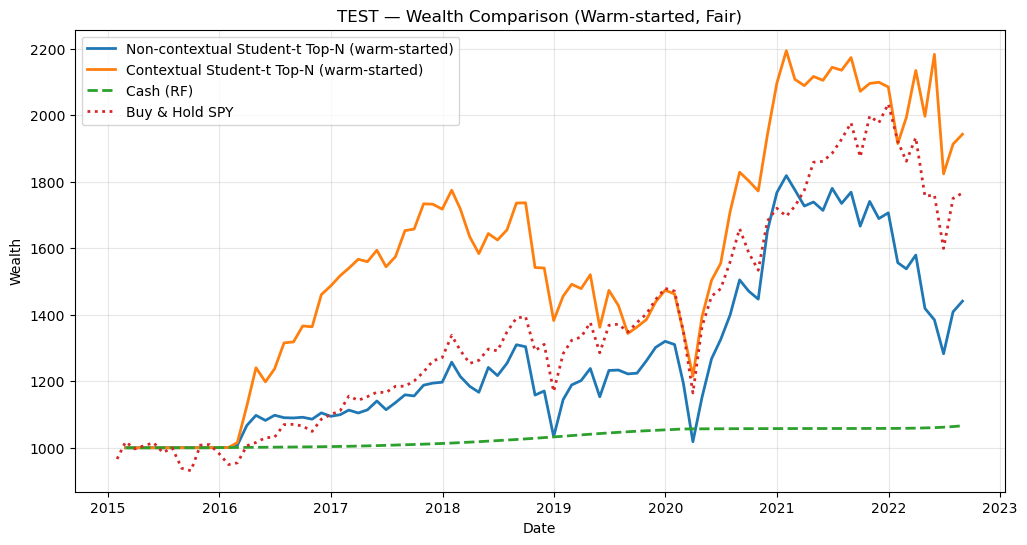

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    res_nonctx_test_warm["wealth"]["Month_hold"],
    res_nonctx_test_warm["wealth"]["wealth"],
    label="Non-contextual Student-t Top-N (warm-started)",
    linewidth=2
)

plt.plot(
    res_ctx_test["wealth"]["Month_hold"],
    res_ctx_test["wealth"]["wealth"],
    label="Contextual Student-t Top-N (warm-started)",
    linewidth=2
)

plt.plot(
    cash_test["Month_hold"],
    cash_test["wealth"],
    label="Cash (RF)",
    linestyle="--",
    linewidth=2
)

plt.plot(
    spy_test["Month"],
    spy_test["wealth"],
    label="Buy & Hold SPY",
    linestyle=":",
    linewidth=2
)

plt.title("TEST — Wealth Comparison (Warm-started, Fair)")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Sanity check: macro columns are already lagged in the panel


In [15]:
col = MACRO_COLS[0]

check = (
    df.sort_values(MONTH_COL)
      .groupby(ETF_COL)[col]
      .apply(lambda x: x.equals(x.shift(0)))
)

check.unique()

array([ True])

## Outperformance vs SPY (percent)


In [16]:
ctx_w = res_ctx_test["wealth"][["Month_hold", "wealth"]].rename(
    columns={"wealth": "wealth_ctx"}
)

spy_w = spy_test.rename(
    columns={"Month": "Month_hold", "wealth": "wealth_spy"}
)

perf_df = (
    ctx_w.merge(spy_w, on="Month_hold", how="inner")
    .sort_values("Month_hold")
)

perf_df["pct_outperformance_vs_spy"] = (
    perf_df["wealth_ctx"] / perf_df["wealth_spy"] - 1.0
)

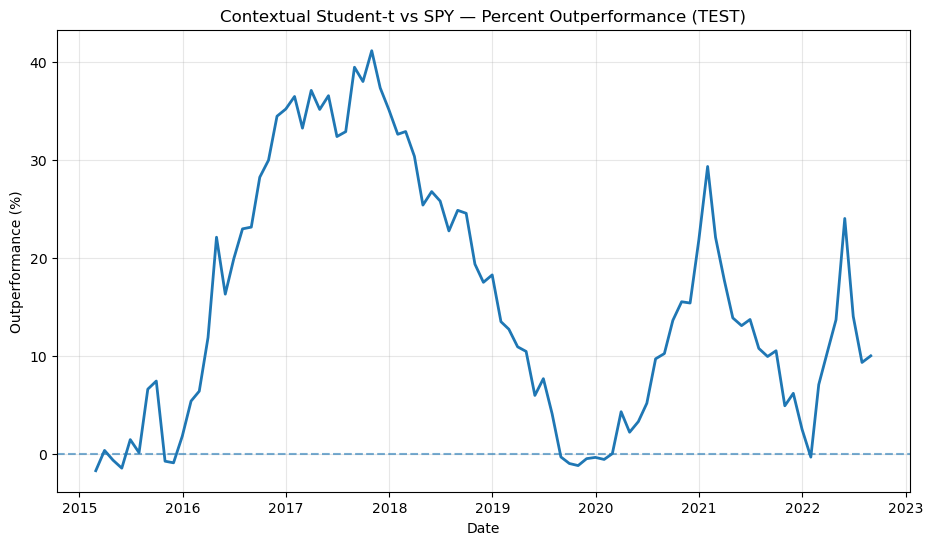

In [17]:
plt.figure(figsize=(11,6))

plt.plot(
    perf_df["Month_hold"],
    100 * perf_df["pct_outperformance_vs_spy"],
    linewidth=2
)

plt.axhline(0.0, linestyle="--", alpha=0.6)
plt.title("Contextual Student-t vs SPY — Percent Outperformance (TEST)")
plt.xlabel("Date")
plt.ylabel("Outperformance (%)")
plt.grid(alpha=0.3)
plt.show()

## ETF holding concentration


In [18]:
def etf_holding_counts(weights_df):
    """
    Count number of months each ETF had positive weight.
    """
    df_pos = weights_df.copy()
    df_pos = df_pos[
        (df_pos["ETF"] != "CASH") & (df_pos["weight"] > 0)
    ]

    counts = (
        df_pos.groupby("ETF")["Month_hold"]
        .nunique()
        .sort_values(ascending=False)
    )
    return counts

In [19]:
ctx_counts = etf_holding_counts(res_ctx_test["weights"])

ctx_counts.head(15)

ETF
QLD     29
ARKG    20
SMH     17
FTXL    16
SLX     16
SOXX    15
KURE    15
FTXN    13
REMX    11
SMMD    10
PSI     10
ZROZ    10
TUR     10
CNRG     9
KGRN     9
Name: Month_hold, dtype: int64

In [20]:
nonctx_counts = etf_holding_counts(res_nonctx_test_warm["weights"])

compare_holdings = pd.DataFrame({
    "Contextual_months_held": ctx_counts,
    "Non_contextual_months_held": nonctx_counts
}).fillna(0).astype(int)

compare_holdings.sort_values(
    "Contextual_months_held",
    ascending=False
).head(15)

,Contextual_months_held,Non_contextual_months_held
ETF,,
QLD,29,64
ARKG,20,22
SMH,17,0
FTXL,16,18
SLX,16,0
KURE,15,3
SOXX,15,0
FTXN,13,1
REMX,11,0


In [21]:
ctx_w = res_ctx_test["wealth"][["Month_hold", "wealth"]].rename(columns={"wealth": "wealth_ctx"})
spy_w = spy_test.rename(columns={"Month": "Month_hold", "wealth": "wealth_spy"})

ret_df = (
    ctx_w.merge(spy_w, on="Month_hold", how="inner")
        .sort_values("Month_hold")
        .reset_index(drop=True)
)

# Monthly returns from wealth
ret_df["r_ctx"] = ret_df["wealth_ctx"].pct_change()
ret_df["r_spy"] = ret_df["wealth_spy"].pct_change()

# Drop first row (NaN returns)
ret_df = ret_df.dropna(subset=["r_ctx", "r_spy"]).reset_index(drop=True)

# Spread
ret_df["r_diff"] = ret_df["r_ctx"] - ret_df["r_spy"]

ret_df.head()

,Month_hold,wealth_ctx,wealth_spy,r_ctx,r_spy,r_diff
0,2015-03-31,1000.041662,996.674487,0.000025,-0.020638,0.020663
1,2015-04-30,1000.058328,1006.670727,0.000017,0.010030,-0.010013
2,2015-05-31,1000.074994,1015.035637,0.000017,0.008309,-0.008293
3,2015-06-30,1000.091660,985.869067,0.000017,-0.028735,0.028751
4,2015-07-31,1000.116659,999.015273,0.000025,0.013335,-0.013310


## Monthly return comparison (contextual vs SPY)


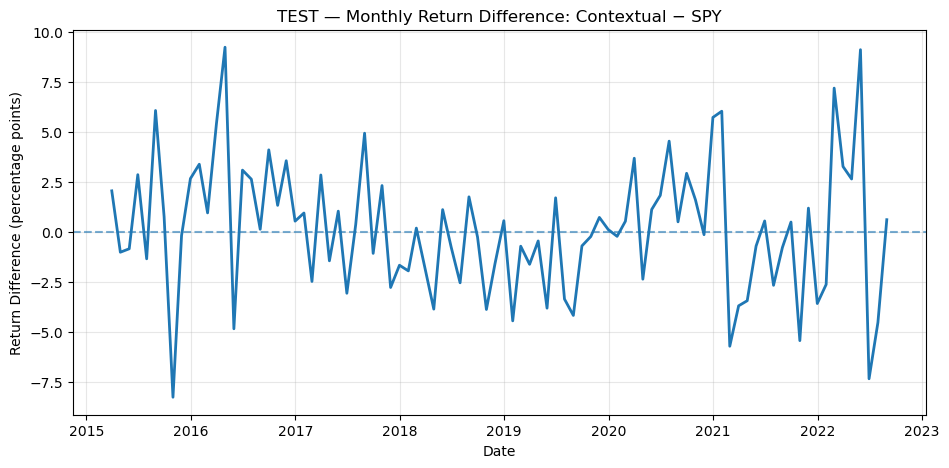

In [22]:
plt.figure(figsize=(11,5))
plt.plot(ret_df["Month_hold"], 100 * ret_df["r_diff"], linewidth=2)

plt.axhline(0.0, linestyle="--", alpha=0.6)
plt.title("TEST — Monthly Return Difference: Contextual − SPY")
plt.xlabel("Date")
plt.ylabel("Return Difference (percentage points)")
plt.grid(alpha=0.3)
plt.show()

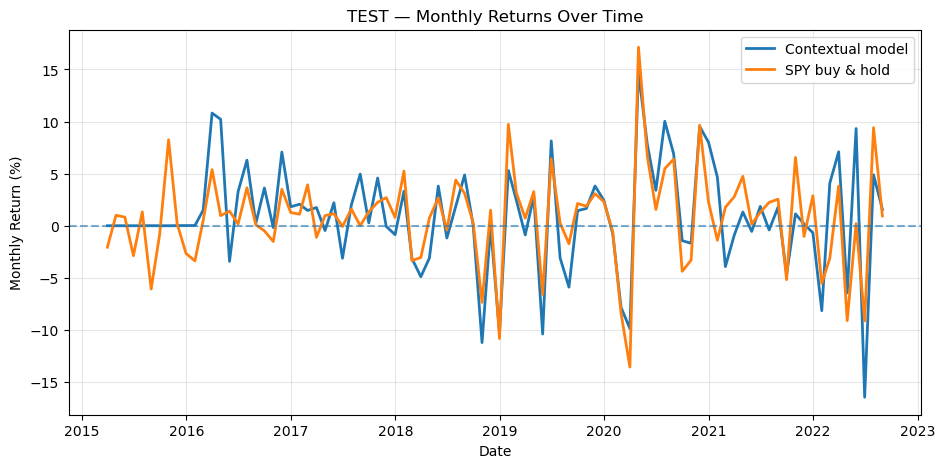

In [23]:
plt.figure(figsize=(11,5))

plt.plot(ret_df["Month_hold"], 100 * ret_df["r_ctx"], label="Contextual model", linewidth=2)
plt.plot(ret_df["Month_hold"], 100 * ret_df["r_spy"], label="SPY buy & hold", linewidth=2)

plt.axhline(0.0, linestyle="--", alpha=0.6)
plt.title("TEST — Monthly Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Summary stats


In [24]:
print("Mean monthly return (ctx):", ret_df["r_ctx"].mean())
print("Mean monthly return (spy):", ret_df["r_spy"].mean())
print("Mean monthly diff (ctx-spy):", ret_df["r_diff"].mean())
print("Pct of months ctx beats spy:", (ret_df["r_diff"] > 0).mean())

Mean monthly return (ctx): 0.00873158143550406
Mean monthly return (spy): 0.007206567125925042
Mean monthly diff (ctx-spy): 0.001525014309579019
Pct of months ctx beats spy: 0.5222222222222223


## Cash-vs-ETF exposure (W_etf) over time


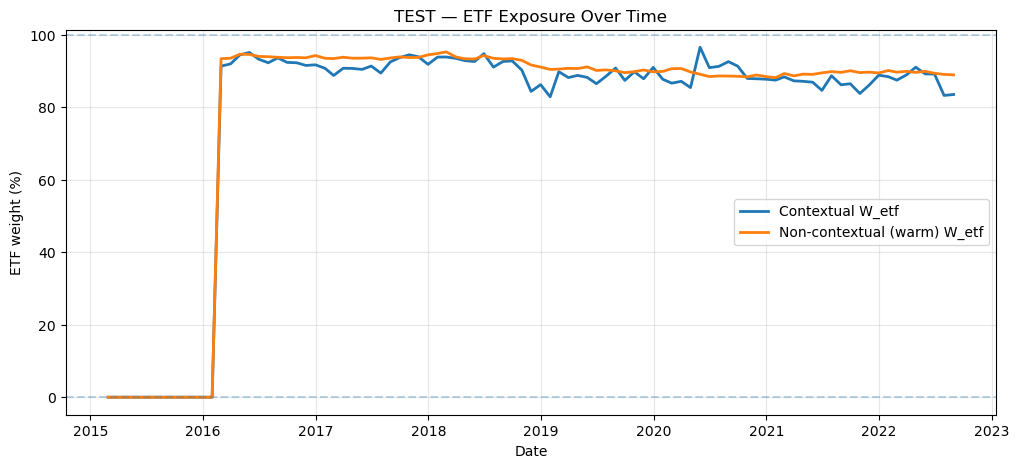

In [25]:
plt.figure(figsize=(12,5))

plt.plot(
    res_ctx_test["wealth"]["Month_hold"],
    100*res_ctx_test["wealth"]["W_etf"],
    linewidth=2,
    label="Contextual W_etf"
)

plt.plot(
    res_nonctx_test_warm["wealth"]["Month_hold"],
    100*res_nonctx_test_warm["wealth"]["W_etf"],
    linewidth=2,
    label="Non-contextual (warm) W_etf"
)

plt.axhline(100, linestyle="--", alpha=0.3)
plt.axhline(0, linestyle="--", alpha=0.3)
plt.title("TEST — ETF Exposure Over Time")
plt.xlabel("Date")
plt.ylabel("ETF weight (%)")
plt.legend()
plt.grid(alpha=0.3)

## (Curiosity) 2005-2020 window replay


In [26]:
k_star = k_star  # or set explicitly, e.g. 800
N_star = N_star  # or set explicitly, e.g. 5

# ---- slice window ----
start_date = pd.Timestamp("2005-01-31")
end_date   = pd.Timestamp("2020-12-31")

df_win = df.copy()
df_win[MONTH_COL] = pd.to_datetime(df_win[MONTH_COL])

df_0520 = df_win[(df_win[MONTH_COL] >= start_date) & (df_win[MONTH_COL] <= end_date)].copy()
df_0520 = df_0520.sort_values([MONTH_COL, ETF_COL]).reset_index(drop=True)

print("Window months:", df_0520[MONTH_COL].min(), "->", df_0520[MONTH_COL].max())
print("Unique months:", df_0520[MONTH_COL].nunique(), "Unique ETFs:", df_0520[ETF_COL].nunique())

# ---- standardize macros within this window (no leakage outside the window) ----
Z_COLS = MACRO_COLS  # or your Z_COLS variable

Z_mean_win = df_0520[Z_COLS].mean()
Z_std_win  = df_0520[Z_COLS].std(ddof=0).replace(0.0, 1.0)

df_0520[Z_COLS] = (df_0520[Z_COLS] - Z_mean_win) / Z_std_win

Window months: 2005-01-31 00:00:00 -> 2020-12-31 00:00:00
Unique months: 192 Unique ETFs: 578


In [27]:
res_ctx_0520 = run_policy_simulation_studentt_contextual_topN(
    df_0520, k=k_star, N=N_star, initial_wealth=1000.0
)

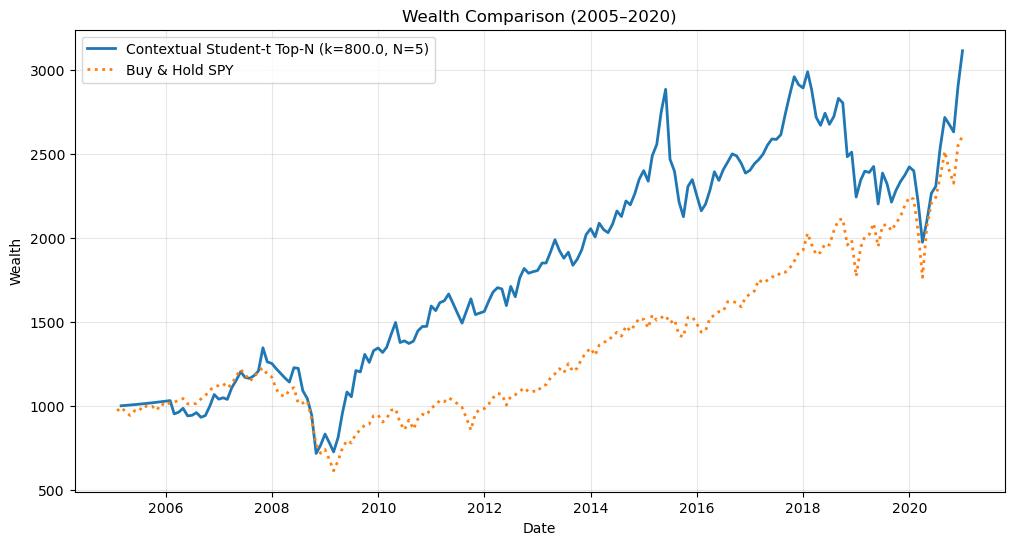

In [28]:
def run_buy_hold_spy_window(df_window, initial_wealth=1000.0):
    spy_df = df_window[df_window[ETF_COL] == "SPY"].sort_values(MONTH_COL).copy()

    wealth = float(initial_wealth)
    out = []
    for _, row in spy_df.iterrows():
        wealth *= (1.0 + float(row[GROWTH_COL]))
        out.append({"Month_hold": row[MONTH_COL], "wealth": wealth})

    return pd.DataFrame(out)

spy_0520 = run_buy_hold_spy_window(df_0520, initial_wealth=1000.0)

plt.figure(figsize=(12,6))

plt.plot(
    res_ctx_0520["wealth"]["Month_hold"],
    res_ctx_0520["wealth"]["wealth"],
    linewidth=2,
    label=f"Contextual Student-t Top-N (k={k_star}, N={N_star})"
)

plt.plot(
    spy_0520["Month_hold"],
    spy_0520["wealth"],
    linewidth=2,
    linestyle=":",
    label="Buy & Hold SPY"
)

plt.title("Wealth Comparison (2005–2020)")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()